In [1]:
from pathlib import Path
from torchvision import datasets
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, random_split
import torchvision.transforms as transforms
import zipfile
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

def unzip_dataset():
    zip_path = Path("dataset.zip")
    extract_dir = Path("dataset")
    
    print("Unzipping dataset...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(extract_dir)
    print("Done!")

cuda


In [2]:
# unzip_dataset()

In [3]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


image_size = 64

transform_train = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

transform_val = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder("dataset")

val_ratio = 0.2
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size

train_subset, val_subset = random_split(dataset, [train_size, val_size])

train_dataset = TransformSubset(train_subset, transform=transform_train)
val_dataset = TransformSubset(val_subset, transform=transform_val)

In [4]:
from torch.utils.data import DataLoader

batch_size = 48

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True
)

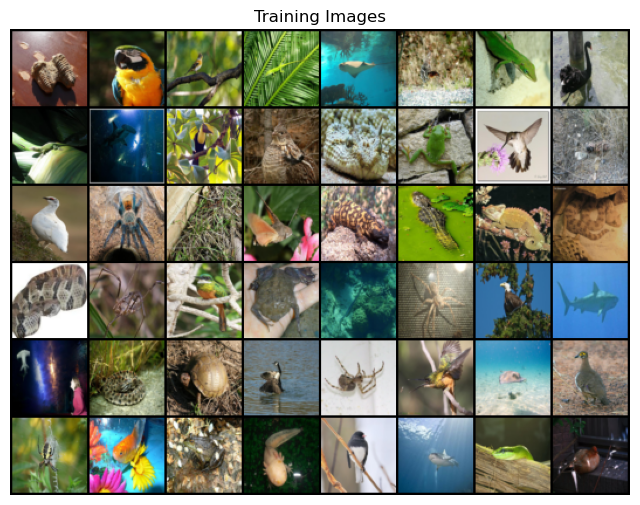

In [5]:
# Plot some training images
real_batch = next(iter(train_loader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

# Model definition

Create models

In [6]:
from models import Generator, Discriminator

nz = 100

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

# For checking how generator is going
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

Checkpoints

Training

In [ ]:
num_epochs = 50
from tqdm import tqdm
import os

img_list = []
start_epoch = 0
g_loss = []
d_loss = []

for epoch in range(start_epoch, num_epochs):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    total_dloss = 0
    total_gloss = 0
    i = 0
    for real_images, s in loop:
        # Discriminator training
        
        D.zero_grad()
        # All real batch
        real = real_images.to(device)
        b_size = s.size()[0]
        label = torch.full((b_size,), 1, dtype=torch.float, device=device)
        output = D(real).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item() # Gradient

        # Train discriminator with fake
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = G(noise)
        label.fill_(0)
        output = D(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        # Update D
        opt_D.step()

        # Generator training
        G.zero_grad()
        # Train with real
        label.fill_(1)
        output = D(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        
        opt_G.step()

        total_dloss += errD.item()
        total_gloss += errG.item()
        i += 1

        loop.set_postfix(DLoss = total_dloss / i, GLoss = total_gloss / i)        

    g_loss.append(total_gloss / i)
    d_loss.append(total_dloss / i)

    with torch.no_grad():
        fake = G(fixed_noise).detach().cpu()
        grid = vutils.make_grid(fake, padding=2, normalize=True)
        img_list.append(grid)
        plt.imshow(np.transpose(grid.numpy(), (1, 2, 0))); plt.title(f"Epoch {epoch + 1}"); plt.axis("off"); plt.savefig(f"outputs/epoch_{epoch + 1}.png"); plt.close()

Epoch 1/50:  87%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                         | 926/1064 [01:47<00:16,  8.57it/s, DLoss=0.732, GLoss=4.3]

In [ ]:
# Plot GLoss
plt.plot(g_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator Training Loss")
plt.savefig(f"outputs/gen_loss.png")
plt.close()

In [ ]:
# Plot DLoss
plt.plot(d_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Discriminator Training Loss")
plt.savefig(f"outputs/disc_loss.png")
plt.close()